# Notebook 4 — Supervised Learning: Classification
**CRISP-DM Phase 4 | Chapter 4: Supervised Learning**

### Algorithms Covered (class reference: classification_algorithms.py)
- Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes
- Support Vector Machine, AdaBoost, Gradient Boosting, XGBoost, LightGBM

### Ethiopian Wealth Prediction Application
- Target: `cons_quint` (1=poorest → 5=wealthiest) — 5-class classification
- Per-region models → regional wealth ranking
- Pairwise region comparison — Chapter 4 inspired analysis


## 1. Setup

In [4]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Class-reference algorithms (Chapter 4)
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import (RandomForestClassifier,
                                    AdaBoostClassifier,
                                    GradientBoostingClassifier)
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.naive_bayes    import GaussianNB
from sklearn.svm            import SVC
from sklearn.metrics        import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Project modules
from data_cleaner       import DataCleaner
from feature_enginner   import FeatureEngineer
from data_preprocesor   import DataPreprocessor
from modeling           import WealthPredictor, ModelEvaluator

COLORS5 = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']
print("✓ Setup complete")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Setup complete


## 2. Data Pipeline (Cleaning → FE → Preprocessing)

In [10]:
df_raw   = pd.read_csv('../data/processed/all_waves_clean.csv')
df_clean = DataCleaner().fit_transform(df_raw)
df       = FeatureEngineer().engineer_all(df_clean)

dp     = DataPreprocessor()
splits = dp.fit(df, test_size=0.20, val_size=0.15)

X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']
y_train, y_val, y_test = splits['y_train'], splits['y_val'], splits['y_test']
feat_names = splits['feature_names']

# Convert target from 1-indexed (1,2,3,4,5) to 0-indexed (0,1,2,3,4) for XGBoost
y_train = y_train - 1
y_val   = y_val - 1
y_test  = y_test - 1

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Classes: {sorted(np.unique(y_train))}")


Train: (16476, 65) | Val: (3803, 65) | Test: (5070, 65)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 3. Chapter 4 Reference — Manual Algorithm Implementations
Mirrors classification_algorithms.py from the class reference.
Each algorithm trained individually before running the full pipeline.


In [6]:
# ── Manual classification — Chapter 4 Lab 4.1 style ────────────────────────
print("Training individual classifiers:")
print("─" * 40)

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                        random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='weighted', zero_division=0)
print(f"Logistic Regression  Acc={lr_acc:.4f}  F1={lr_f1:.4f}")

# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=12, class_weight='balanced',
                             random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)
dt_f1   = f1_score(y_test, dt_pred, average='weighted', zero_division=0)
print(f"Decision Tree        Acc={dt_acc:.4f}  F1={dt_f1:.4f}")

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='weighted', zero_division=0)
print(f"Random Forest        Acc={rf_acc:.4f}  F1={rf_f1:.4f}")

# 4. KNN (Chapter 4: needs scaled features — already scaled by pipeline)
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc  = accuracy_score(y_test, knn_pred)
knn_f1   = f1_score(y_test, knn_pred, average='weighted', zero_division=0)
print(f"KNN (k=7)            Acc={knn_acc:.4f}  F1={knn_f1:.4f}")

# 5. Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_acc  = accuracy_score(y_test, nb_pred)
nb_f1   = f1_score(y_test, nb_pred, average='weighted', zero_division=0)
print(f"Naive Bayes          Acc={nb_acc:.4f}  F1={nb_f1:.4f}")

# 6. SVM
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc  = accuracy_score(y_test, svm_pred)
svm_f1   = f1_score(y_test, svm_pred, average='weighted', zero_division=0)
print(f"SVM (RBF)            Acc={svm_acc:.4f}  F1={svm_f1:.4f}")

# 7. AdaBoost
ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.1,
                          random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
ada_acc  = accuracy_score(y_test, ada_pred)
ada_f1   = f1_score(y_test, ada_pred, average='weighted', zero_division=0)
print(f"AdaBoost             Acc={ada_acc:.4f}  F1={ada_f1:.4f}")


Training individual classifiers (Chapter 4 reference):
───────────────────────────────────────────────────────
Logistic Regression  Acc=0.3982  F1=0.3870
Decision Tree        Acc=0.3507  F1=0.3556
Random Forest        Acc=0.4047  F1=0.3944
KNN (k=7)            Acc=0.3542  F1=0.3434
Naive Bayes          Acc=0.3302  F1=0.3158
SVM (RBF)            Acc=0.3949  F1=0.3898
AdaBoost             Acc=0.3669  F1=0.2855


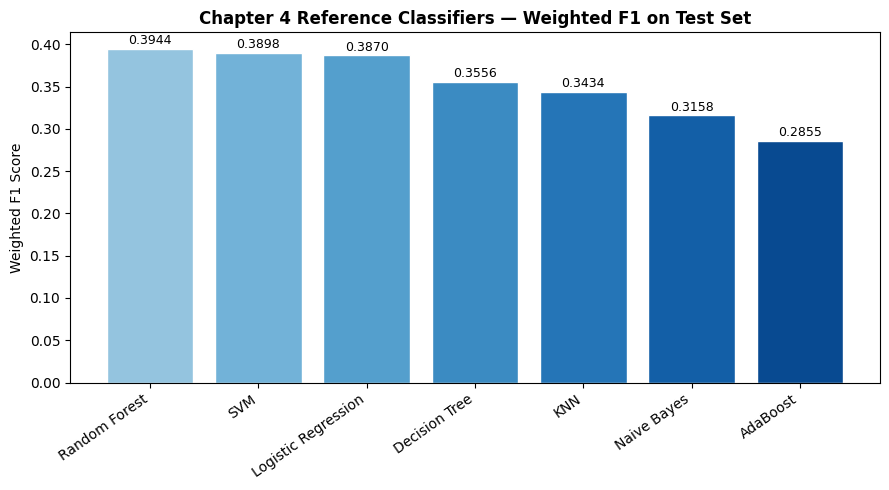

,Model,Accuracy,Weighted_F1
2,Random Forest,0.4047,0.3944
5,SVM,0.3949,0.3898
0,Logistic Regression,0.3982,0.3870
1,Decision Tree,0.3507,0.3556
3,KNN,0.3542,0.3434
4,Naive Bayes,0.3302,0.3158
6,AdaBoost,0.3669,0.2855


In [ ]:
# Manual model comparison table (compare all models)
manual_results = pd.DataFrame([
    {'Model':'Logistic Regression', 'Accuracy':lr_acc,  'Weighted_F1':lr_f1},
    {'Model':'Decision Tree',       'Accuracy':dt_acc,  'Weighted_F1':dt_f1},
    {'Model':'Random Forest',       'Accuracy':rf_acc,  'Weighted_F1':rf_f1},
    {'Model':'KNN',                 'Accuracy':knn_acc, 'Weighted_F1':knn_f1},
    {'Model':'Naive Bayes',         'Accuracy':nb_acc,  'Weighted_F1':nb_f1},
    {'Model':'SVM',                 'Accuracy':svm_acc, 'Weighted_F1':svm_f1},
    {'Model':'AdaBoost',            'Accuracy':ada_acc, 'Weighted_F1':ada_f1},
]).sort_values('Weighted_F1', ascending=False).round(4)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(manual_results['Model'],
              manual_results['Weighted_F1'],
              color=plt.cm.Blues(np.linspace(0.4, 0.9, len(manual_results))),
              edgecolor='white')
ax.set_title('Classifiers — Weighted F1 on Test Set',
             fontweight='bold')
ax.set_ylabel('Weighted F1 Score')
ax.set_xticklabels(manual_results['Model'], rotation=35, ha='right')
for bar, v in zip(bars, manual_results['Weighted_F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/manual_classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
manual_results


## 4. KNN Hyperparameter Tuning — k Selection (Chapter 4 Reference)
Chapter 4 Lab 4.1 Exercise 7: tune n_neighbors by evaluating accuracy at each k.


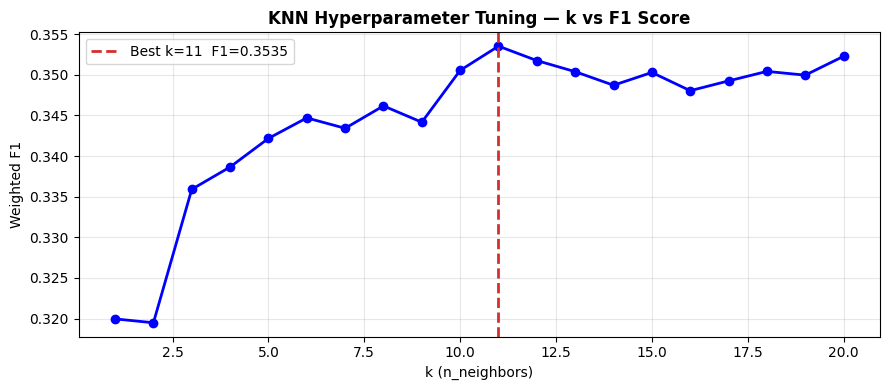

Optimal k = 11  (F1 = 0.3535)


In [8]:
k_values    = range(1, 21)
knn_f1_list = []

for k in k_values:
    knn_k    = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_k.fit(X_train, y_train)
    pred_k   = knn_k.predict(X_test)
    knn_f1_list.append(f1_score(y_test, pred_k, average='weighted', zero_division=0))

best_k  = k_values[np.argmax(knn_f1_list)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_values, knn_f1_list, 'bo-', lw=2, ms=6)
ax.axvline(best_k, color='#d32f2f', ls='--', lw=2,
           label=f'Best k={best_k}  F1={max(knn_f1_list):.4f}')
ax.set_xlabel('k (n_neighbors)'); ax.set_ylabel('Weighted F1')
ax.set_title('KNN Hyperparameter Tuning — k vs F1 Score', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/knn_k_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Optimal k = {best_k}  (F1 = {max(knn_f1_list):.4f})")


## 5. WealthPredictor — Full Pipeline (All Models + Boosting)
Extends manual classifiers with XGBoost/LightGBM and adds per-region models.


In [11]:
wp      = WealthPredictor(random_state=42)
results = wp.train_evaluate(X_train, y_train, X_test, y_test, cv_folds=5)
results



✓ Best model: Random Forest (weighted F1 = 0.3955)


,model,accuracy,precision,recall,weighted_f1,macro_f1,cv_f1_mean,cv_f1_std
0,Random Forest,0.4045,0.3968,0.4045,0.3955,0.3684,0.3849,0.0064
1,LightGBM,0.3955,0.3885,0.3955,0.3886,0.3611,0.3846,0.0069
2,Logistic Regression,0.3982,0.3865,0.3982,0.3870,0.3582,0.3753,0.0043
3,XGBoost,0.4142,0.3753,0.4142,0.3849,0.3547,0.3806,0.0059
4,Gradient Boosting,0.4116,0.3754,0.4116,0.3841,0.3546,0.3814,0.0058
5,Decision Tree,0.3434,0.3652,0.3434,0.3501,0.3260,0.3440,0.0046
6,KNN,0.3542,0.3369,0.3542,0.3434,0.3137,0.3528,0.0105
7,Naive Bayes,0.3302,0.3651,0.3302,0.3158,0.2913,0.3138,0.0027
8,AdaBoost,0.3669,0.2369,0.3669,0.2855,0.2402,0.2805,0.0030


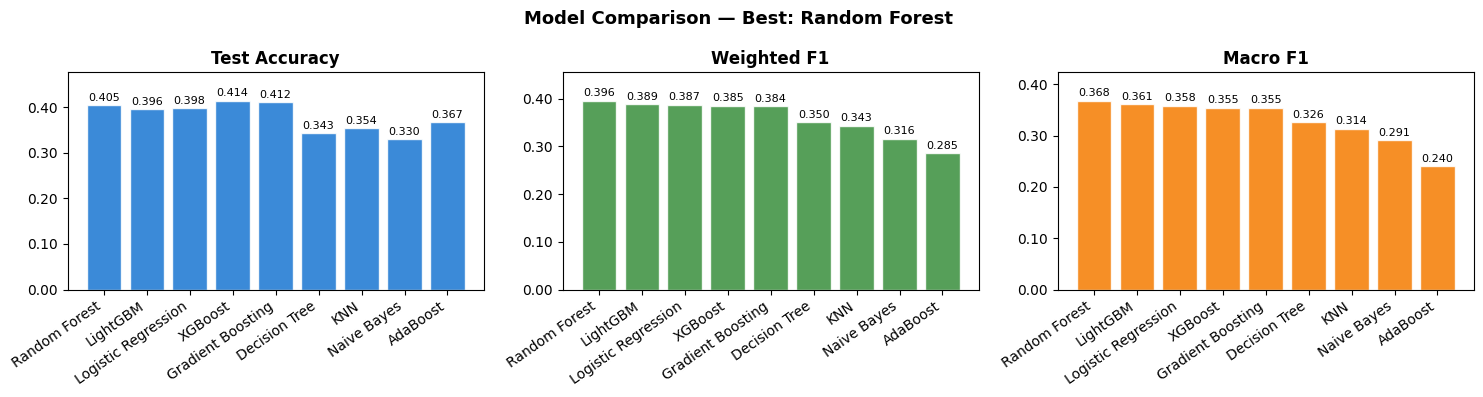

In [12]:
# Model comparison chart (accuracy, weighted F1, macro F1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color, title in zip(
    axes,
    ['accuracy','weighted_f1','macro_f1'],
    ['#1976D2','#388e3c','#f57c00'],
    ['Test Accuracy','Weighted F1','Macro F1']):
    bars = ax.bar(results['model'], results[col], color=color,
                  edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(results['model'], rotation=35, ha='right')
    ax.set_ylim(0, min(1.0, results[col].max() * 1.15))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    for bar, v in zip(bars, results[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.suptitle(f"Model Comparison — Best: {wp.best_name_}", fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Best Model — Classification Report & Confusion Matrix

In [13]:
print(f"Best model: {wp.best_name_}")
print()
cr_df = wp.classification_report_df(X_test, y_test)
cr_df


Best model: Random Forest



,precision,recall,f1-score,support
Q1 (poorest),0.3806,0.5804,0.4597,777.0000
Q2 (),0.2695,0.2770,0.2732,787.0000
Q3 (),0.2414,0.1962,0.2165,897.0000
Q4 (),0.3402,0.2474,0.2865,1071.0000
Q5 (wealthiest),0.6001,0.6118,0.6059,1538.0000
accuracy,0.4045,0.4045,0.4045,0.4045
macro avg,0.3664,0.3826,0.3684,5070.0000
weighted avg,0.3968,0.4045,0.3955,5070.0000


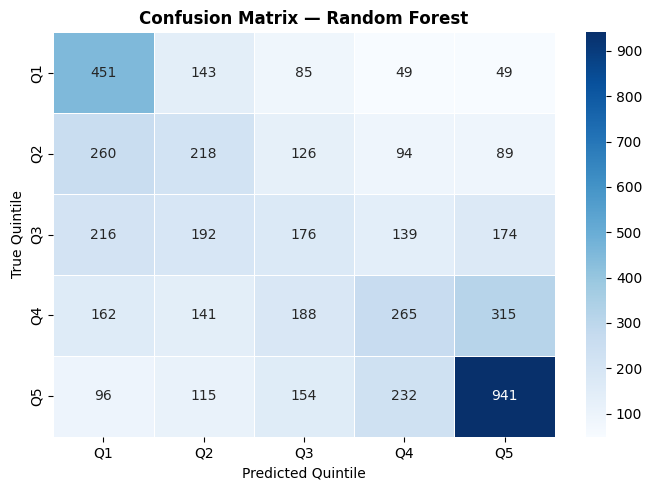

In [14]:
cm_df = wp.confusion_matrix_df(X_test, y_test)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title(f'Confusion Matrix — {wp.best_name_}', fontweight='bold')
ax.set_xlabel('Predicted Quintile'); ax.set_ylabel('True Quintile')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Feature Importance — Top 20 Predictors of Wealth

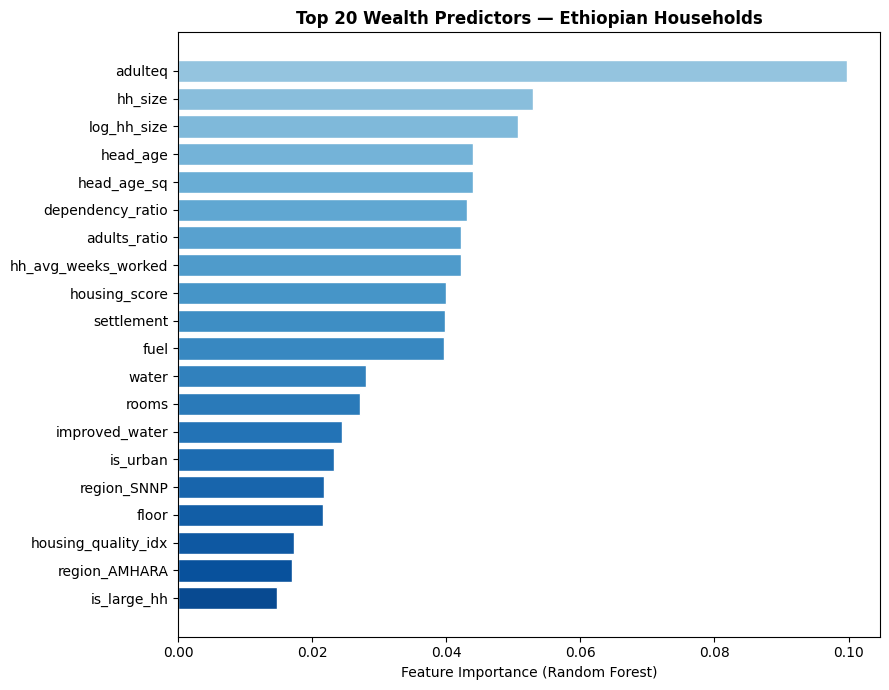

,feature,importance
0,adulteq,0.099712
1,hh_size,0.052862
2,log_hh_size,0.050731
3,head_age,0.043970
4,head_age_sq,0.043940
5,dependency_ratio,0.043012
6,adults_ratio,0.042238
7,hh_avg_weeks_worked,0.042119
8,housing_score,0.039916
9,settlement,0.039781


In [15]:
imp_df = wp.feature_importance(feat_names, top_n=20)

fig, ax = plt.subplots(figsize=(9, 7))
clrs = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_df)))[::-1]
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=clrs, edgecolor='white')
ax.set_xlabel(f'Feature Importance ({wp.best_name_})')
ax.set_title('Top 20 Wealth Predictors — Ethiopian Households', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
imp_df


## 8. GridSearchCV Hyperparameter Tuning (Chapter 4 Reference)
Chapter 4 Lab 4.4 Exercise 9: GridSearchCV for optimal model parameters.


In [16]:
# Tune best tree-based model (skip if XGBoost unavailable)
try:
    best_model_name = wp.best_name_
    if best_model_name in ('XGBoost','LightGBM','Random Forest','Gradient Boosting'):
        print(f"Tuning {best_model_name} with GridSearchCV (cv=3)…")
        tune_results = wp.tune(X_train, y_train,
                               model_name=best_model_name, cv_folds=3)
        print(f"Best params : {tune_results.attrs.get('best_params_')}")
        print(f"Best CV F1  : {tune_results.attrs.get('best_cv_score')}")
        tune_results.head(10)
    else:
        print(f"Skipping tuning for {best_model_name} (no grid defined)")
except Exception as e:
    print(f"GridSearch skipped: {e}")


Tuning Random Forest with GridSearchCV (cv=3)…
Best params: {'max_depth': 12, 'min_samples_leaf': 5, 'n_estimators': 200}  |  CV F1: 0.3821
Best params : None
Best CV F1  : 0.3821


## 9. Per-Region Models — Regional Wealth Ranking

In [17]:
reg_df = wp.train_per_region(df, feat_names, test_size=0.20)
print(f"Regions trained: {len(reg_df)}")
reg_df


Regions trained: 11


,region,n_households,accuracy,weighted_f1,mean_pred_quintile
0,HARAR,1431,0.3937,0.3909,4.111
1,ADDIS ABABA,1946,0.3897,0.3998,4.010
2,DIRE DAWA,1627,0.4540,0.4544,3.831
3,TIGRAY,2223,0.3820,0.3828,3.557
4,AFAR,1179,0.4110,0.4130,3.470
5,GAMBELA,1288,0.3721,0.3699,3.450
6,OROMIA,4096,0.3610,0.3616,3.404
7,SOMALI,1909,0.3691,0.3619,3.178
8,BENISHANGUL GUMUZ,940,0.3351,0.3346,3.138
9,SNNP,4503,0.3818,0.3818,2.901


In [18]:
ranking = wp.regional_ranking(reg_df)
ranking


,region,n_households,accuracy,weighted_f1,mean_pred_quintile,wealth_rank,pct_q1_poorest,pct_q5_wealthiest
0,HARAR,1431,0.3937,0.3909,4.111,1,1.7,47.4
1,ADDIS ABABA,1946,0.3897,0.3998,4.010,2,1.5,41.0
2,DIRE DAWA,1627,0.4540,0.4544,3.831,3,5.5,38.0
3,TIGRAY,2223,0.3820,0.3828,3.557,4,8.5,33.7
4,AFAR,1179,0.4110,0.4130,3.470,5,10.6,30.5
5,GAMBELA,1288,0.3721,0.3699,3.450,6,14.0,33.7
6,OROMIA,4096,0.3610,0.3616,3.404,7,12.0,30.5
7,SOMALI,1909,0.3691,0.3619,3.178,8,20.4,28.5
8,BENISHANGUL GUMUZ,940,0.3351,0.3346,3.138,9,21.3,26.6
9,SNNP,4503,0.3818,0.3818,2.901,10,28.0,23.0


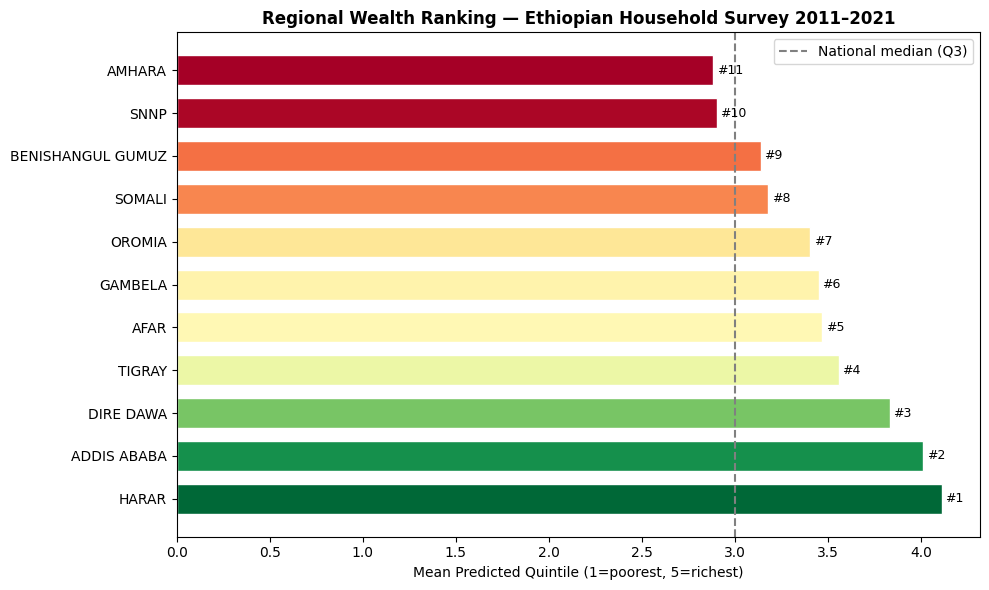

In [19]:
# Regional wealth ranking chart
fig, ax = plt.subplots(figsize=(10, 6))
norm_q = (ranking['mean_pred_quintile'] - ranking['mean_pred_quintile'].min())
norm_q = norm_q / (norm_q.max() or 1)
bar_clr = plt.cm.RdYlGn(norm_q.values)

bars = ax.barh(ranking['region'], ranking['mean_pred_quintile'],
               color=bar_clr, edgecolor='white', height=0.7)
ax.axvline(3, color='grey', ls='--', lw=1.5, label='National median (Q3)')
ax.set_xlabel('Mean Predicted Quintile (1=poorest, 5=richest)')
ax.set_title('Regional Wealth Ranking — Ethiopian Household Survey 2011–2021',
             fontweight='bold')
ax.legend()
for bar, row in zip(bars, ranking.itertuples()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'#{row.wealth_rank}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/regional_ranking.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Pairwise Regional Wealth Comparison

In [20]:
# Key comparisons: richest vs poorest; conflict region
for ra, rb in [('ADDIS ABABA','AMHARA'),('TIGRAY','OROMIA'),
               ('ADDIS ABABA','SOMALI')]:
    try:
        comp = wp.compare_regions(ra, rb)
        print(f"\n── {ra} vs {rb} ──────────────────────────────────")
        print(comp.to_string(index=False))
    except KeyError as e:
        print(f"Skipped: {e}")



── ADDIS ABABA vs AMHARA ──────────────────────────────────
     region  n_households  mean_pred_quintile  pct_q1_poorest  pct_q5_wealthiest  Q1  Q2  Q3  Q4  Q5  accuracy  weighted_f1   wealthier
ADDIS ABABA          1946               4.010             1.5               41.0   6  32  74 118 160    0.3897       0.3998 ← wealthier
     AMHARA          4207               2.884            23.2               19.2 195 176 165 144 162    0.2957       0.2939            

── TIGRAY vs OROMIA ──────────────────────────────────
region  n_households  mean_pred_quintile  pct_q1_poorest  pct_q5_wealthiest  Q1  Q2  Q3  Q4  Q5  accuracy  weighted_f1   wealthier
TIGRAY          2223               3.557             8.5               33.7  38  71  91  95 150     0.382       0.3828 ← wealthier
OROMIA          4096               3.404            12.0               30.5  98 133 179 160 250     0.361       0.3616            

── ADDIS ABABA vs SOMALI ──────────────────────────────────
     region  n_househ

In [21]:
# All pairs sorted by wealth gap
all_pairs = wp.compare_all_pairs()
print(f"Total pairs: {len(all_pairs)}")
all_pairs.head(10)


Total pairs: 55


,region_a,region_b,mean_q_a,mean_q_b,wealth_gap,wealthier
0,AMHARA,HARAR,2.884,4.111,1.228,HARAR
1,HARAR,SNNP,4.111,2.901,1.210,HARAR
2,ADDIS ABABA,AMHARA,4.010,2.884,1.127,ADDIS ABABA
3,ADDIS ABABA,SNNP,4.010,2.901,1.109,ADDIS ABABA
4,BENISHANGUL GUMUZ,HARAR,3.138,4.111,0.973,HARAR
5,AMHARA,DIRE DAWA,2.884,3.831,0.948,DIRE DAWA
6,HARAR,SOMALI,4.111,3.178,0.933,HARAR
7,DIRE DAWA,SNNP,3.831,2.901,0.930,DIRE DAWA
8,ADDIS ABABA,BENISHANGUL GUMUZ,4.010,3.138,0.872,ADDIS ABABA
9,ADDIS ABABA,SOMALI,4.010,3.178,0.832,ADDIS ABABA


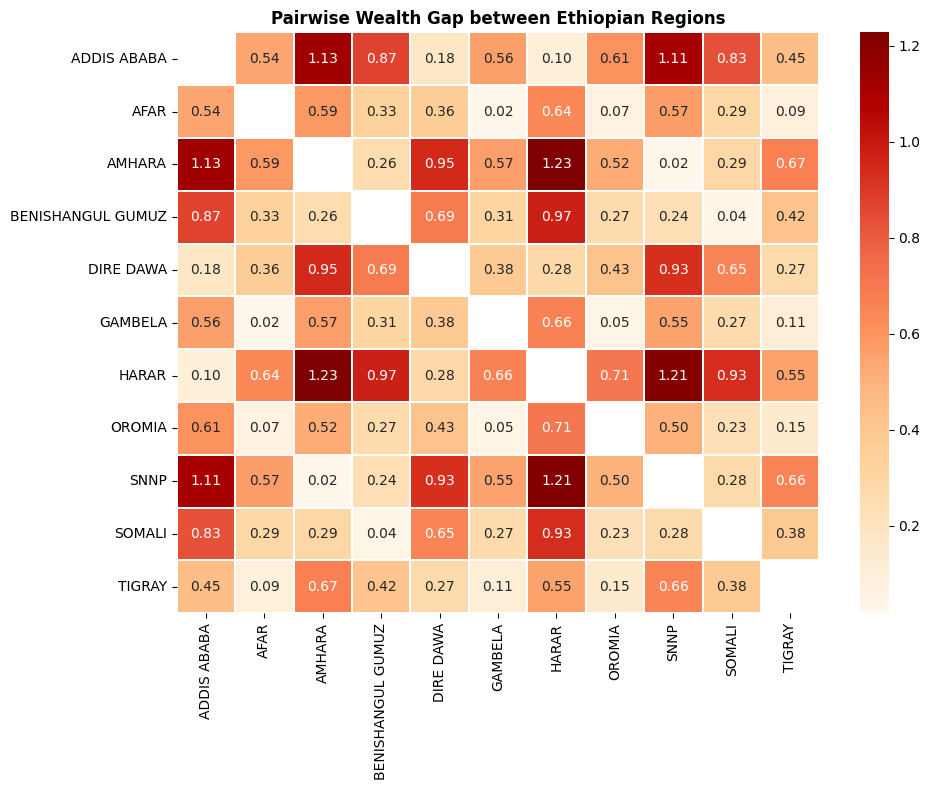

In [22]:
# Wealth gap heatmap
try:
    regions = sorted(wp.region_models_.keys())
    n       = len(regions)
    matrix  = pd.DataFrame(np.nan, index=regions, columns=regions)
    for _, row in all_pairs.iterrows():
        matrix.loc[row['region_a'], row['region_b']] = row['wealth_gap']
        matrix.loc[row['region_b'], row['region_a']] = row['wealth_gap']

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='OrRd',
                linewidths=0.3, ax=ax, mask=matrix.isna())
    ax.set_title('Pairwise Wealth Gap between Ethiopian Regions',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/pairwise_wealth_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Heatmap skipped: {e}")


## 11. Save All Models

In [23]:
wp.save('../models')
dp.save('../models/preprocessor.pkl')
print("✓ All models saved to ../models/")


Best model saved → ..\models\best_model.pkl
Preprocessor saved → ..\models\preprocessor.pkl
✓ All models saved to ../models/
